<a href="https://colab.research.google.com/github/ketanp23/deeplearningclass/blob/main/DL_Lab10_Regularization_and_Generalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DL Lab 10 · Regularization & Generalization

> **Deep Learning foundations — Lab 10 (Part II).** A deeper companion to **Lab 5 (Deep Feedforward Nets)**. Run top to bottom
> (Runtime → Run all), read the plain-English notes, and finish the **Your turn 🧪** cell. Built from scratch with
> NumPy so nothing is hidden.

### In plain English
Lab 5 introduced capacity — too little and you underfit, too much and you overfit. This lab is the practitioner's
toolkit for landing in the middle: seeing the **bias–variance trade-off**, taming a flexible model with **L2 weight
decay**, using **dropout**, and knowing when to stop with **early stopping**. The goal is never to fit the training
data — it's to fit the *process that made it*.

In [1]:
import numpy as np, matplotlib.pyplot as plt
VIOLET,CYAN,AMBER,ROSE="#6C5CE7","#22D3EE","#F59E0B","#FB7185"
rng=np.random.default_rng(0)
truth=lambda x: np.sin(2*np.pi*x)
xt=np.sort(rng.uniform(0,1,18)); yt=truth(xt)+rng.normal(0,0.18,18)   # small noisy training set
xg=np.linspace(0,1,200)

## 1 · Overfitting as capacity grows (polynomial degree)

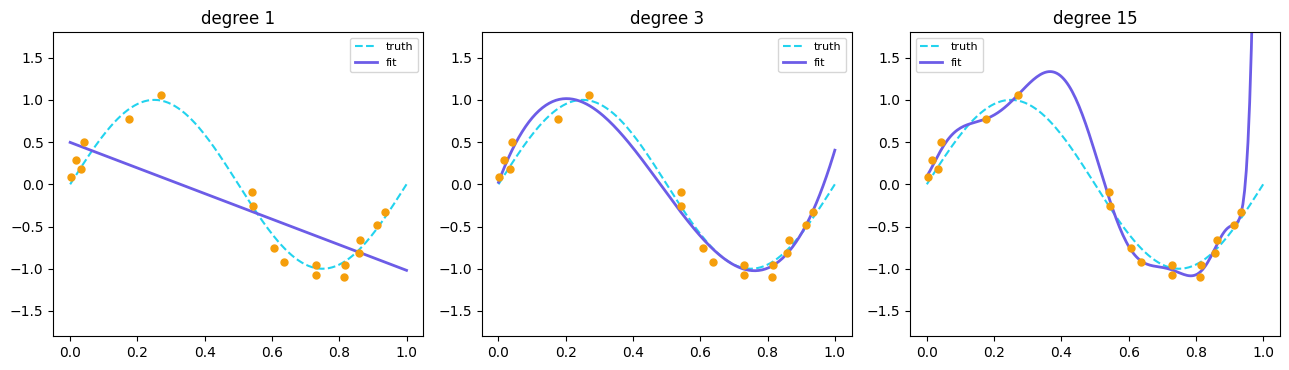

degree 1 underfits; degree 3 is about right; degree 15 wiggles through the noise (overfit).


In [2]:
def poly_fit(x,y,deg,lam=0.0):
    Xp=np.vander(x,deg+1)                       # design matrix
    A=Xp.T@Xp + lam*np.eye(deg+1)               # ridge term
    return np.linalg.solve(A, Xp.T@y)
def poly_eval(w,x): return np.vander(x,len(w))@w

fig,ax=plt.subplots(1,3,figsize=(13,3.8))
for a,deg in zip(ax,[1,3,15]):
    w=poly_fit(xt,yt,deg)
    a.scatter(xt,yt,color=AMBER,s=25,zorder=3); a.plot(xg,truth(xg),color=CYAN,ls="--",label="truth")
    a.plot(xg,poly_eval(w,xg),color=VIOLET,lw=2,label="fit"); a.set_ylim(-1.8,1.8)
    a.set_title(f"degree {deg}"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("degree 1 underfits; degree 3 is about right; degree 15 wiggles through the noise (overfit).")

## 2 · The bias–variance U-curve

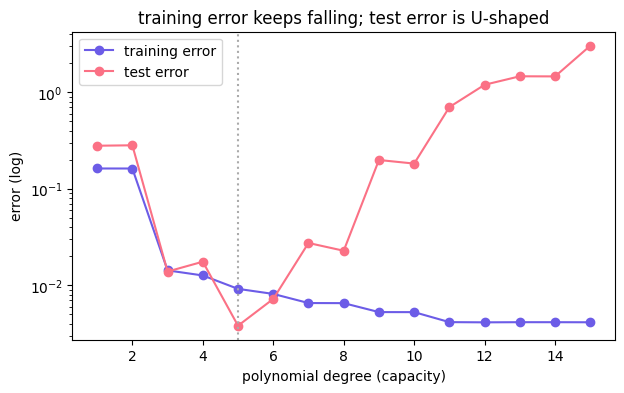

best degree by TEST error: 5 — training error would have told you to keep going.


In [3]:
xtest=np.linspace(0,1,200); ytest=truth(xtest)
degs=range(1,16); tr,te=[],[]
for d in degs:
    w=poly_fit(xt,yt,d)
    tr.append(np.mean((poly_eval(w,xt)-yt)**2))
    te.append(np.mean((poly_eval(w,xtest)-ytest)**2))
plt.figure(figsize=(7,4))
plt.plot(list(degs),tr,'o-',color=VIOLET,label="training error")
plt.plot(list(degs),te,'o-',color=ROSE,label="test error")
plt.axvline(list(degs)[int(np.argmin(te))],color="#aaa",ls=":")
plt.yscale("log"); plt.xlabel("polynomial degree (capacity)"); plt.ylabel("error (log)")
plt.title("training error keeps falling; test error is U-shaped"); plt.legend(); plt.show()
print("best degree by TEST error:", list(degs)[int(np.argmin(te))], "— training error would have told you to keep going.")

## 3 · L2 regularization (weight decay) tames a flexible model

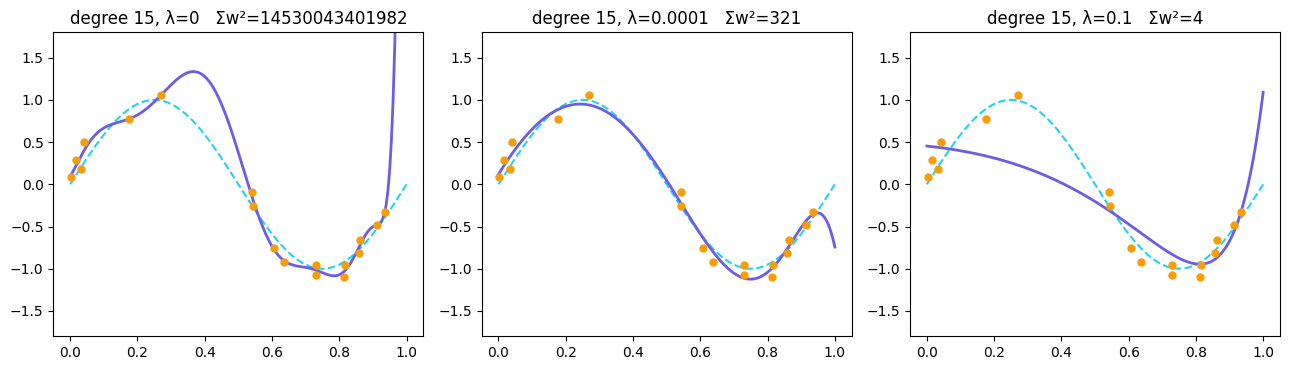

Same degree-15 model. Raising λ shrinks the weights, and the wild wiggles relax into the true curve.


In [4]:
deg=15
fig,ax=plt.subplots(1,3,figsize=(13,3.8))
for a,lam in zip(ax,[0.0,1e-4,1e-1]):
    w=poly_fit(xt,yt,deg,lam=lam)
    a.scatter(xt,yt,color=AMBER,s=25,zorder=3); a.plot(xg,truth(xg),color=CYAN,ls="--")
    a.plot(xg,poly_eval(w,xg),color=VIOLET,lw=2)
    a.set_ylim(-1.8,1.8); a.set_title(f"degree 15, λ={lam:g}   Σw²={np.sum(w**2):.0f}")
plt.tight_layout(); plt.show()
print("Same degree-15 model. Raising λ shrinks the weights, and the wild wiggles relax into the true curve.")

## 4 · Dropout on a small classifier
Dropout randomly zeroes hidden units during training, forcing the network not to rely on any one of them. We train a
small ReLU MLP on a noisy 2-class problem, with and without dropout, and compare the **generalization gap**.

In [5]:
def make_blobs(n=120, seed=0):
    r=np.random.default_rng(seed); n2=n//2
    a=r.normal([-1,-1],0.9,(n2,2)); b=r.normal([1,1],0.9,(n2,2))
    return np.vstack([a,b]), np.r_[np.zeros(n2),np.ones(n2)]
Xtr,ytr=make_blobs(120,0); Xte,yte=make_blobs(400,1)

class DropMLP:
    def __init__(self,sizes,seed=0):
        r=np.random.default_rng(seed)
        self.W=[r.standard_normal((sizes[i],sizes[i+1]))*np.sqrt(2/sizes[i]) for i in range(len(sizes)-1)]
        self.b=[np.zeros(sizes[i+1]) for i in range(len(sizes)-1)]
    def forward(self,X,drop=0.0,train=False):
        self.a=[X]; self.m=[]; a=X; L=len(self.W)
        for i in range(L):
            z=a@self.W[i]+self.b[i]
            if i<L-1:
                a=np.maximum(0,z)
                if train and drop>0:
                    mask=(np.random.rand(*a.shape)>drop)/(1-drop); a=a*mask; self.m.append(mask)
                else: self.m.append(None)
            else: a=1/(1+np.exp(-z))
            self.a.append(a)
        return a
    def fit(self,X,y,epochs=1500,lr=0.1,drop=0.0):
        y=y.reshape(-1,1); n=len(X)
        for e in range(epochs):
            out=self.forward(X,drop=drop,train=True); d=(out-y)*out*(1-out)
            for i in range(len(self.W)-1,-1,-1):
                gW=self.a[i].T@d/n; gb=d.mean(0)
                if i>0:
                    da=d@self.W[i].T
                    if self.m[i-1] is not None: da=da*self.m[i-1]
                    d=da*(self.a[i]>0)
                self.W[i]-=lr*gW; self.b[i]-=lr*gb
    def acc(self,X,y): return ((self.forward(X).ravel()>0.5).astype(int)==y).mean()

for drop in [0.0,0.4]:
    m=DropMLP([2,64,64,1],seed=3); m.fit(Xtr,ytr,epochs=1500,lr=0.1,drop=drop)
    print(f"dropout={drop:>3}:  train acc {m.acc(Xtr,ytr):.3f}   test acc {m.acc(Xte,yte):.3f}   gap {m.acc(Xtr,ytr)-m.acc(Xte,yte):+.3f}")

dropout=0.0:  train acc 0.933   test acc 0.953   gap -0.019
dropout=0.4:  train acc 0.917   test acc 0.950   gap -0.033


## 5 · Early stopping

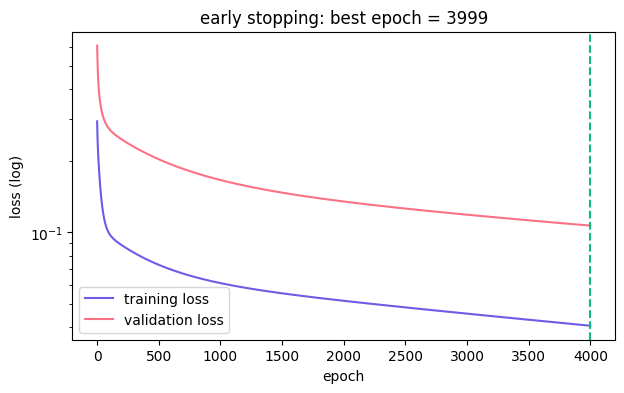

validation loss bottoms at epoch 3999; training past it just memorizes noise.


In [6]:
# train a high-capacity poly-feature model with gradient descent, tracking val loss
Xtr2=np.vander(xt,12);
xval=np.sort(rng.uniform(0,1,40)); yval=truth(xval)+rng.normal(0,0.18,40); Xval=np.vander(xval,12)
w=np.zeros(12); tr_h,va_h=[],[]
for e in range(4000):
    g=Xtr2.T@(Xtr2@w-yt)/len(xt); w-=0.5*g
    tr_h.append(np.mean((Xtr2@w-yt)**2)); va_h.append(np.mean((Xval@w-yval)**2))
best=int(np.argmin(va_h))
plt.figure(figsize=(7,4))
plt.plot(tr_h,color=VIOLET,label="training loss"); plt.plot(va_h,color=ROSE,label="validation loss")
plt.axvline(best,color="#10B981",ls="--"); plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("loss (log)")
plt.title(f"early stopping: best epoch = {best}"); plt.legend(); plt.show()
print(f"validation loss bottoms at epoch {best}; training past it just memorizes noise.")

## Your turn 🧪
1. In section 2, add a **third** curve: test error for a model trained on 5× more data. Does the U-curve's bottom move
   right (more data supports more capacity)?
2. Sweep dropout from 0 to 0.7 in section 4 and plot the train/test gap. Where does dropout start to *hurt*?
3. Combine ideas: degree-15 polynomial **with** λ chosen by the validation set. Does it beat the best un-regularized
   degree from section 2?

In [7]:
# Your turn: pick λ for the degree-15 model using validation error
deg=15; lams=np.logspace(-6,0,25); best_lam,best_err=None,1e9
for lam in lams:
    w=poly_fit(xt,yt,deg,lam=lam); err=np.mean((poly_eval(w,xval)-yval)**2)
    if err<best_err: best_err,best_lam=err,lam
print(f"best λ = {best_lam:.2e}  with validation MSE {best_err:.3f}")

best λ = 5.62e-06  with validation MSE 0.032
